<h1 style="color: #CEDDF4;">DEPI Round 4, MS Data Engineer and AI Track</h1>
<h2 style="color: #CEDDF4;" >Final Project: Gold and Oil Prediction System</h2>
<h3 style="color: #CEDDF4;" > Part (2): Python Code for Machine Learning and Modeling</h3>
<h4 style="color: #CEDDF4;" > 2.2: ML for Brent Oil Price</h4>

In this section, we aim to forecast brent oil prices - which is used in determining the financial policy in Egyptian Budget - over a specified timeframe. For the scope of this academic exercise, the prediction window is set from **January 1, 2026, to April 30, 2026**. 

To evaluate performance, we will implement and compare two distinct modeling approaches:

*   **Top Features Model:** This approach utilizes a curated subset of variables identified as having the most significant impact on brent oil prices. The exact number of features retained is an adjustable hyperparameter that can be optimized during the model's fine-tuning phase.
*   **Full Feature Model:** This baseline approach incorporates all available features within the dataset to generate predictions.

<h4 style="color: #CEDDF4;" >1. Import Libraries</h4>

In [1]:
import os
import math
from pathlib import Path
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
import lightgbm as lgb
import joblib
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np

In [2]:
base_dir = Path.cwd()
#raw data path to contain all raw files gathered either manually, web scraping or APIs
raw_data_dir=base_dir/'raw data'
#cleaned data path, will be separated into two main folders which are: market data (contains the data with daily logs) and macroeconomic data
##cleaned market data
cleaned_market_data_dir=base_dir/'cleaned data'/'market_data'
##cleaned macroeconomic data
cleaned_macro_data_dir=base_dir/'cleaned data'/'macroeconomic_data'
##ai modeling data
ai_data_dir=base_dir/'ai model'

<h4 style="color: #CEDDF4;" > 4. OIL PRICE PREDICTION</h4>

<h4 style="color: #CEDDF4;" >4.1 Data Reading</h4>



In [3]:
df = pd.read_csv(ai_data_dir/'new_master_table.csv')

<h4 style="color: #CEDDF4;" > 4.2 Setup</h4>

In [4]:
target_col = 'brent_oil_price_usd'
df = df.copy()

<h4 style="color: #CEDDF4;" > 4.3 Time preprocessing</h4>

In [5]:
df['date'] = pd.to_datetime(df['date'], dayfirst=False, format='mixed', errors='coerce')  # ← False
df = df.sort_values('date')

<h4 style="color: #CEDDF4;" > 4.4 Leakage removal</h4>

In [6]:
leakage_keywords = [
    '_open_', '_high_', '_low_',
    'gpr_event',
    'ai_gpr_Unnamed',
    'gold_price_oz_egp',
    'cbe_inflations_headline_inflation_yy',
    'cbe_inflations_core_inflation_yy'
]

leakage_exact = [
    'brent_oil_open_usd',
    'brent_oil_high_usd',
    'brent_oil_low_usd'
]

df = df.drop(columns=[
    c for c in df.columns
    if any(k in c for k in leakage_keywords) or c in leakage_exact
], errors='ignore')

<h4 style="color: #CEDDF4;" > 4.5 Feature Engineering</h4>

In [7]:
df['net_energy_imports'] = df['energy_fuel_imports'] - df['energy_fuel_exports']
df['opec_pressure'] = df['opec_basket_value'] / df['brent_oil_price_usd']
df['geo_risk_oil'] = df['ai_gpr_gpr_oil']
df['oil_vol_x_vix'] = df['oil_vi_value'] * df['vix_price_usd']
df['oil_sp500'] = df['brent_oil_price_usd'] / df['sp500_price_usd']
df['oil_x_dxy'] = df['brent_oil_price_usd'] * df['dollarindex_value']
df['copper_oil_ratio'] = df['copper_price_usd'] / df['brent_oil_price_usd']
df['wti_brent_spread'] = df['wti_price_usd'] - df['brent_oil_price_usd']

<h4 style="color: #CEDDF4;" > 4.6 Target engineering</h4>

In [8]:
df['log_price'] = np.log(df[target_col])
df['return'] = df['log_price'].diff()

df['target'] = df['return'].rolling(5).mean().shift(-1)
df['target'] = df['target'].clip(-0.04, 0.04)


<h4 style="color: #CEDDF4;" > 4.7 Lag features</h4>

In [9]:
for lag in [1,2,3,5,10,20]:
    df[f'return_lag_{lag}'] = df['return'].shift(lag)

df['log_price_lag1'] = df['log_price'].shift(1)


<h4 style="color: #CEDDF4;" > 4.8 Volatility and momentum </h4>

In [10]:
df['vol_7'] = df['return'].rolling(7).std().shift(1)
df['vol_20'] = df['return'].rolling(20).std().shift(1)
df['mom_7'] = df['return'].rolling(7).mean().shift(1)
df['price_trend_7'] = df[target_col].rolling(7).mean().shift(1)

<h4 style="color: #CEDDF4;" > 4.9 Data cleaning </h4>

In [11]:
df = df.dropna().reset_index(drop=True)

<h4 style="color: #CEDDF4;" > 4.10 Feature list </h4>

In [12]:
features = [c for c in df.columns if c not in ['date', target_col, 'target']]

<h4 style="color: #CEDDF4;" > 4.11 Train-test split</h4>

In [13]:
train = df[df['date'] <= '2025-12-31']
test = df[ (df['date'] > '2025-12-31') & (df['date'] <= '2026-04-30') ] #testing period

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

<h4 style="color: #CEDDF4;" > 4.12 time series Cross-validation</h4>

In [14]:
tscv = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv.split(X_train)):
    model_cv = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6
    )

    model_cv.fit(X_train.iloc[tr], y_train.iloc[tr])
    pred = model_cv.predict(X_train.iloc[val])

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train.iloc[val], pred))
    print("DIR:", np.mean(np.sign(y_train.iloc[val]) == np.sign(pred)))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10457
[LightGBM] [Info] Number of data points in the train set: 607, number of used features: 139
[LightGBM] [Info] Start training from score 0.001030
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

<h4 style="color: #CEDDF4;" > 4.13 Base model for importance</h4>

In [15]:
base_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

base_model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003778 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17332
[LightGBM] [Info] Number of data points in the train set: 3632, number of used features: 140
[LightGBM] [Info] Start training from score 0.000217


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;" > 4.14 Feature importance extraction </h4>

In [16]:
importance = pd.Series(
    base_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

<h4 style="color: #CEDDF4;" > 4.15 Select top features </h4>

In [17]:
top_k=20
top_features = importance.head(top_k).index.tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

<h4 style="color: #CEDDF4;" > 4.16 Train full model (all features) </h4>

In [18]:
model_full = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_full.fit(X_train, y_train)

#model saving into pickle file

with open(ai_data_dir/'models'/"standalone_oil_price_full_model.pkl", "wb") as f:
    pickle.dump(model_full, f)

pred_full = model_full.predict(X_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002962 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17332
[LightGBM] [Info] Number of data points in the train set: 3632, number of used features: 140
[LightGBM] [Info] Start training from score 0.000217


<h4 style="color: #CEDDF4;" > 4.17 Train top features model </h4>

In [19]:
model_top = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',

    n_estimators=3000,
    learning_rate=0.02,

    num_leaves=128,
    max_depth=10,

    min_child_samples=10,
    min_child_weight=1e-3,

    subsample=0.9,
    subsample_freq=1,

    colsample_bytree=0.9,

    reg_alpha=0.1,
    reg_lambda=0.3,

    random_state=42
)

model_top.fit(X_train_top, y_train)

#model saving into pickle file

with open(ai_data_dir/'models'/"standalone_oil_price_top_model.pkl", "wb") as f:
    pickle.dump(model_top, f)

pred_top = model_top.predict(X_test_top)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000552 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 3632, number of used features: 20
[LightGBM] [Info] Start training from score 0.000217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

<h4 style="color: #CEDDF4;" > 4.18 Price reconstruction </h4>

In [20]:
start_price = train[target_col].iloc[-1]

prices_full = [start_price]
for r in pred_full:
    prices_full.append(prices_full[-1] * np.exp(r))
prices_full = prices_full[1:]

prices_top = [start_price]
for r in pred_top:
    prices_top.append(prices_top[-1] * np.exp(r))
prices_top = prices_top[1:]

test = test.copy()
test['pred_price_full'] = prices_full
test['pred_price_top'] = prices_top


<h4 style="color: #CEDDF4;" > 4.19 Evaluation</h4>

In [21]:
mae_full = mean_absolute_error(test[target_col], test['pred_price_full'])
dir_full = np.mean(np.sign(test['target']) == np.sign(pred_full))

mae_top = mean_absolute_error(test[target_col], test['pred_price_top'])
dir_top = np.mean(np.sign(test['target']) == np.sign(pred_top))

print("Full Model MAE:", mae_full)
print("Full Model Direction:", dir_full)

print("Top Features MAE:", mae_top)
print("Top Features Direction:", dir_top)

Full Model MAE: 11.919314975111927
Full Model Direction: 0.7899159663865546
Top Features MAE: 5.270834124034344
Top Features Direction: 0.7983193277310925


<h4 style="color: #CEDDF4;" > 4.20 Visualization </h4>

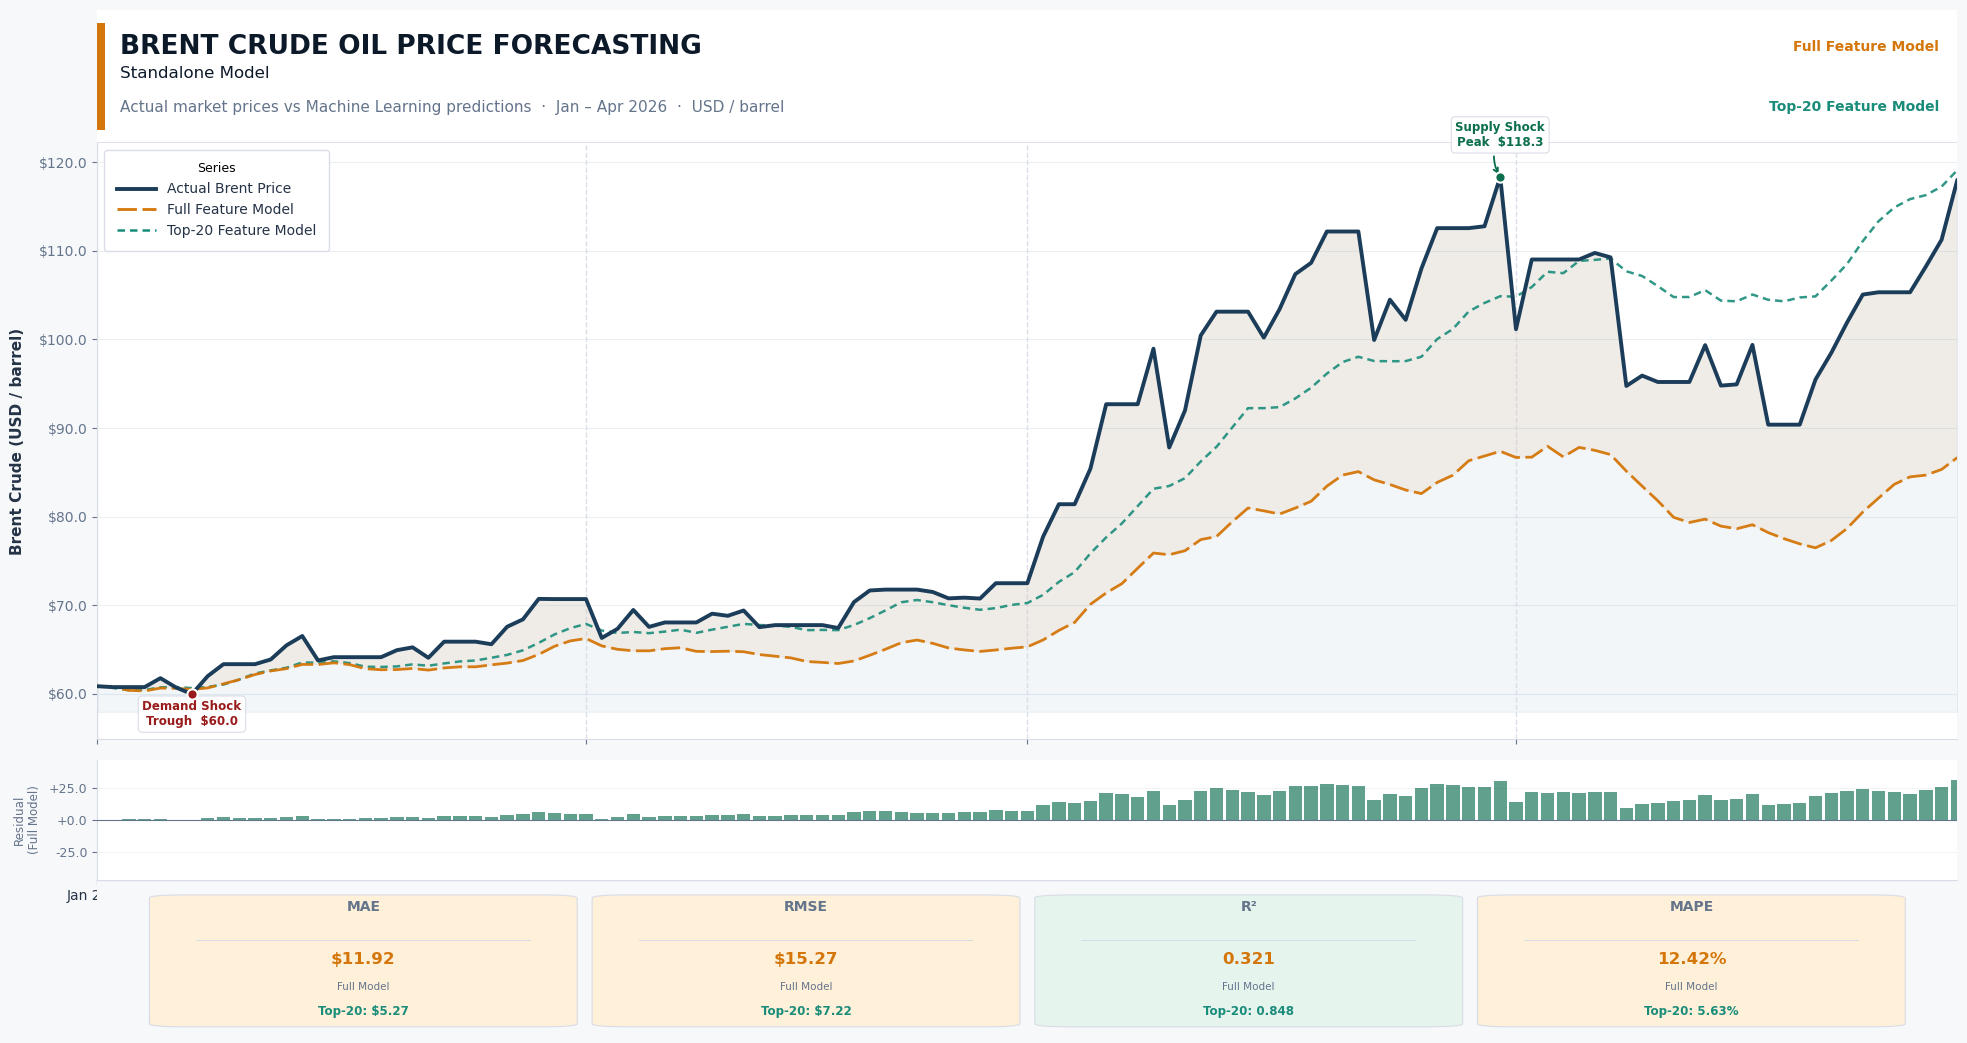

In [22]:
# ── KPI helper ────────────────────────────────────────────────────────────────
def kpis(a, p):
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    r2   = 1 - np.sum((a-p)**2) / np.sum((a-a.mean())**2)
    mape = np.mean(np.abs((a-p)/a)) * 100
    return mae, rmse, r2, mape

plot_df   = test.sort_values('date').copy()
dates     = plot_df['date'].values
actual    = plot_df[target_col].values
full_pred = plot_df['pred_price_full'].values
top_pred  = plot_df['pred_price_top'].values

mae_f, rmse_f, r2_f, mape_f = kpis(actual, full_pred)
mae_t, rmse_t, r2_t, mape_t = kpis(actual, top_pred)

# ── Palette ───────────────────────────────────────────────────────────────────
PAGE, WHITE, BORDER, GRID_C = '#F7F8FA', '#FFFFFF', '#D8DCE6', '#ECEEF4'
OIL_LINE, OIL_FILL          = '#1C3D5A', '#2E6DA4'
AMBER, TEAL                 = '#D4760A', '#1A8C7A'
TEXT_H, TEXT_B, TEXT_M      = '#0C1929', '#253347', '#64748B'
GREEN_KPI, GREEN_BG         = '#0B6E4F', '#E6F4EE'
RED_KPI                     = '#991B1B'
AMBER_KPI, AMBER_BG         = '#7C4700', '#FEF0D9'

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                          hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

# ── Header ────────────────────────────────────────────────────────────────────
ax_h = fig.add_subplot(outer[0])
ax_h.set_facecolor(WHITE); ax_h.set_xlim(0,1); ax_h.set_ylim(0,1)
for sp in ax_h.spines.values(): sp.set_visible(False)
ax_h.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_h.add_patch(mpatches.FancyBboxPatch((0,0.10),0.004,0.80,
    boxstyle='square,pad=0', fc=AMBER, ec='none',
    transform=ax_h.transAxes, clip_on=False))
ax_h.text(0.012,0.72,'BRENT CRUDE OIL PRICE FORECASTING',
    transform=ax_h.transAxes, fontsize=19, fontweight='bold', color=TEXT_H, va='center')
ax_h.text(0.012, 0.52, 'Standalone Model', transform=ax_h.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
ax_h.text(0.012,0.27,
    'Actual market prices vs Machine Learning predictions  ·  Jan – Apr 2026  ·  USD / barrel',
    transform=ax_h.transAxes, fontsize=11, color=TEXT_M, va='center')
ax_h.text(0.99,0.72,'Full Feature Model',
    transform=ax_h.transAxes, fontsize=10, fontweight='bold', color=AMBER, ha='right', va='center')
ax_h.text(0.99,0.27,f'Top-{top_k} Feature Model',
    transform=ax_h.transAxes, fontsize=10, fontweight='bold', color=TEAL,  ha='right', va='center')
ax_h.axhline(0, color=BORDER, linewidth=1.2)

# ── Chart + residual ──────────────────────────────────────────────────────────
inner = gridspec.GridSpecFromSubplotSpec(2,1, subplot_spec=outer[1],
                                         height_ratios=[5,1], hspace=0.06)
ax   = fig.add_subplot(inner[0])
ax_r = fig.add_subplot(inner[1], sharex=ax)

for a in [ax, ax_r]:
    a.set_facecolor(WHITE); a.tick_params(colors=TEXT_M, labelsize=10)
    for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

# Fills
ax.fill_between(dates, actual, actual.min()-2, color=OIL_FILL, alpha=0.06, zorder=1)
ax.fill_between(dates, actual, full_pred,
    where=(actual>=full_pred), color=AMBER, alpha=0.07, zorder=2, interpolate=True)
ax.fill_between(dates, actual, full_pred,
    where=(actual<full_pred),  color=TEAL,  alpha=0.07, zorder=2, interpolate=True)

# Lines
ax.plot(dates, actual,    color=OIL_LINE, linewidth=2.8, zorder=6,
        solid_capstyle='round', label='Actual Brent Price')
ax.plot(dates, full_pred, color=AMBER, linewidth=2.0, linestyle=(0,(7,2)), zorder=5, alpha=0.95)
ax.plot(dates, top_pred,  color=TEAL,  linewidth=1.8, linestyle=(0,(3,2)), zorder=4, alpha=0.90)

# Month dividers
for ms in pd.date_range(plot_df['date'].min(), plot_df['date'].max(), freq='MS'):
    ax.axvline(ms, color=BORDER, linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
ax.set_xlim(dates[0], dates[-1])

# Peak & trough callouts
pidx=np.argmax(actual); pval=actual[pidx]; pdate=dates[pidx]
tidx=np.argmin(actual); tval=actual[tidx]; tdate=dates[tidx]
for x,y,lbl,col,ya,arc in [
    (pdate, pval, f'Supply Shock\nPeak  ${pval:.1f}',   GREEN_KPI, pval+3.5,  0.3),
    (tdate, tval, f'Demand Shock\nTrough  ${tval:.1f}', RED_KPI,   tval-3.5, -0.3),
]:
    ax.annotate(lbl, xy=(x,y), xytext=(pd.Timestamp(x)+pd.Timedelta(days=0),ya),
        color=col, fontsize=8.5, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=col,
            connectionstyle=f'arc3,rad={arc}', lw=1.3),
        bbox=dict(boxstyle='round,pad=0.35', fc=WHITE, ec=BORDER, alpha=0.95, lw=0.8),
        zorder=10)
    ax.scatter([x],[y], color=col, s=55, zorder=11, edgecolors=WHITE, linewidths=1.5)

# Axes
ax.yaxis.grid(True, color=GRID_C, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}'))
ax.set_ylabel('Brent Crude (USD / barrel)', color=TEXT_B, fontsize=11,
              fontweight='bold', labelpad=10)
ax.tick_params(axis='x', labelbottom=False)
ax.legend(handles=[
    Line2D([0],[0], color=OIL_LINE, linewidth=2.8,                      label='Actual Brent Price'),
    Line2D([0],[0], color=AMBER,    linewidth=2.0, linestyle=(0,(7,2)), label='Full Feature Model'),
    Line2D([0],[0], color=TEAL,     linewidth=1.8, linestyle=(0,(3,2)), label=f'Top-{top_k} Feature Model'),
], loc='upper left', frameon=True, framealpha=0.95, facecolor=WHITE, edgecolor=BORDER,
   labelcolor=TEXT_B, fontsize=10, borderpad=0.9, handlelength=2.8,
   title='Series', title_fontsize=9)

# Residual strip
res = actual - full_pred
ax_r.bar(dates, res, color=[GREEN_KPI if v>=0 else RED_KPI for v in res],
         alpha=0.65, width=0.85, zorder=3)
ax_r.axhline(0, color=TEXT_M, linewidth=0.8, zorder=4)
ax_r.yaxis.grid(True, color=GRID_C, linewidth=0.5, zorder=0); ax_r.set_axisbelow(True)
ax_r.set_ylabel('Residual\n(Full Model)', color=TEXT_M, fontsize=8.5, labelpad=6)
ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:+.1f}'))
ax_r.tick_params(colors=TEXT_M, labelsize=9)
pad = max(abs(res.min()), abs(res.max())) * 1.5
ax_r.set_ylim(-pad, pad)
ax_r.xaxis.set_major_locator(mdates.MonthLocator())
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_r.tick_params(axis='x', labelsize=10, colors=TEXT_B)

# ── KPI strip ────────────────────────────────────────────────────────────────
ax_k = fig.add_subplot(outer[2])
ax_k.set_facecolor(PAGE); ax_k.set_xlim(0,1); ax_k.set_ylim(0,1)
for sp in ax_k.spines.values(): sp.set_visible(False)
ax_k.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_k.axhline(1.0, color=BORDER, linewidth=1.0)

for i,(metric,vf,vt,tcol,bgcol) in enumerate([
    ('MAE',  f'${mae_f:.2f}',  f'${mae_t:.2f}',  AMBER_KPI, AMBER_BG),
    ('RMSE', f'${rmse_f:.2f}', f'${rmse_t:.2f}', AMBER_KPI, AMBER_BG),
    ('R²',   f'{r2_f:.3f}',    f'{r2_t:.3f}',     GREEN_KPI, GREEN_BG),
    ('MAPE', f'{mape_f:.2f}%', f'{mape_t:.2f}%', AMBER_KPI, AMBER_BG),
]):
    card_w=0.19; gap=(1.0-4*card_w)/5
    x0=gap+i*(card_w+gap); xc=x0+card_w/2
    ax_k.add_patch(mpatches.FancyBboxPatch((x0,0.06),card_w,0.82,
        boxstyle='round,pad=0.02', fc=bgcol, ec=BORDER, linewidth=0.8,
        transform=ax_k.transAxes, clip_on=False))
    ax_k.text(xc,0.82,metric, transform=ax_k.transAxes,
        ha='center',va='center',fontsize=10,fontweight='bold',color=TEXT_M)
    ax_k.add_patch(mpatches.FancyBboxPatch((x0+0.005,0.60),card_w-0.01,0.005,
        boxstyle='square,pad=0',fc=BORDER,ec='none',
        transform=ax_k.transAxes,clip_on=False))
    ax_k.text(xc,0.48,vf, transform=ax_k.transAxes,
        ha='center',va='center',fontsize=12,fontweight='bold',color=AMBER)
    ax_k.text(xc,0.30,'Full Model', transform=ax_k.transAxes,
        ha='center',va='center',fontsize=7.5,color=TEXT_M)
    ax_k.text(xc,0.14,f'Top-{top_k}: {vt}', transform=ax_k.transAxes,
        ha='center',va='center',fontsize=8.5,fontweight='bold',color=TEAL)

plt.savefig(ai_data_dir / 'visualizations'/'standalone_oil_price_prediction_model.png',
            dpi=300, bbox_inches='tight', facecolor=PAGE)
plt.show()

<h4 style="color: #CEDDF4;" > 4.21 Oil price prediction </h4>

In [23]:
# get latest available row from full dataset (not just test)
latest_row = df.iloc[-1:]

# build features exactly like training
latest_features = latest_row[top_features]

# predict next-day return
pred_return_tomorrow = model_top.predict(latest_features)[0]

# get last known price
last_price = latest_row[target_col].values[0]

# convert return to price
pred_price_tomorrow = last_price * np.exp(pred_return_tomorrow)

print("Predicted Brent Oil Price Tomorrow:", pred_price_tomorrow)

Predicted Brent Oil Price Tomorrow: 119.90706618569111
